<!--announcements-->
<center>
    <img src="network.png" width="400px" /></a>
</center>

<h2>Introduction</h2>

In this project, you will implement some neural networks to solve regression and image classification problems. This project will introduce you to some of the basics of implementing and training these powerful models. For this, we will be exploring more into the deep end with Course staffs' favorite ML framework: PyTorch!

For full documentation and details, here is their site https://pytorch.org/. PyTorch is an open source machine learning library based on the Torch library, used for applications such as computer vision and natural language processing, primarily developed by Facebook's AI Research lab. Pytorch is very neat because, as you have seen your assignments, in order to do gradient descent we've had to calculate gradient manually. No more! Pytorch performs automatic differentation, as long as we use their functions in our code.

From this project, we will be implementing two neural network models learned in class:
* Multi-Layer Perceptrons
* Convolutional Neural Networks

We will also implement a __training loop__ and __testing loop__ in PyTorch for a handwriting classification task, MNIST.

Note: Because we are working with Pytorch functions and Modules, we will be using excusively Pytorch tensors instead of numpy arrays. Let's begin by importing some of the necessary functions.

<strong>How to submit:</strong> You can submit your code using the <strong>Submit</strong> button above. This button will send any code below surrounded by <strong>#&lt;GRADED&gt;</strong><strong>#&lt;/GRADED&gt;</strong> tags below to the autograder, which will then run several tests over your code. By clicking on the <strong>Details</strong> dropdown next to the Submit button, you will be able to view your submission report once the autograder has completed running. This submission report contains a summary of the tests you have failed or passed, as well as a log of any errors generated by your code when we ran it.

Note that this may take a while depending on how long your code takes to run! Once your code is submitted you may navigate away from the page as you desire -- the most recent submission report will always be available from the Details menu.

<p><strong>Evaluation:</strong> Your code will be autograded for technical
correctness and--on some assignments--speed. Please <em>do not</em> change the names of any provided functions or classes within the code, or you will wreak havoc on the autograder. Furthermore, <em>any code not surrounded by <strong>#&lt;GRADED&gt;</strong><strong>#&lt;/GRADED&gt;</strong> tags will not be run by the autograder</em>. However, the correctness of your implementation -- not the autograder's output -- will be the final judge of your score.  If necessary, we will review and grade assignments individually to ensure that you receive due credit for your work.

<p><strong>Academic Integrity:</strong> We will be checking your code against other submissions in the class for logical redundancy. If you copy someone else's code and submit it with minor changes, we will know. These cheat detectors are quite hard to fool, so please don't try. We trust you all to submit your own work only; <em>please</em> don't let us down. If you do, we will pursue the strongest consequences available to us.

<p><strong>Getting Help:</strong> You are not alone!  If you find yourself stuck  on something, contact the course staff for help.  Office hours, section, and the <a href="https://edstem.org/us/courses/94295/discussion">EdStem</a> are there for your support; please use them.  If you can't make our office hours, let us know and we will schedule more.  We want these projects to be rewarding and instructional, not frustrating and demoralizing.  But, we don't know when or how to help unless you ask.
    
<p><strong>Policies:</strong> All the policies described on the course website are applicable as is, including the policy on Academic Integrity (we are participating in Accepting Responsibility, a supplement to the Code of Academic Integrity). For more information, see: <a href="https://www.cs.cornell.edu/courses/cs3780/2025sp/#Policies">Course Policies</a>.


<p><strong>P5 Deadlines:</strong> The deadline for this project is on <strong>May 5 (11:59 pm EST)</strong>. The late deadline is on <strong>May 7</strong>. Submissions beyond the late due date will not be recorded.

In [10]:
%matplotlib notebook

#<GRADED>
import numpy as np
from numpy.matlib import repmat
import sys
import time
import matplotlib
import matplotlib.pyplot as plt
import ipywidgets as widgets

from scipy.stats import linregress

# new torch imports
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# new vision-dataset-related torch imports
import torchvision
import torchvision.datasets as dset
import torchvision.transforms as transforms

# misc imports
import random
#</GRADED>

<h2>Regression on Non-linear Functions</h2>

Recall from Project 4, where you were tasked to use gradient descent to find the parameters of a simple linear regression problem. We will re-visit the regression problem, but this time for _nonlinear_ data!

Before, we were able to model a simple linear function. Let's see if we can move onto a more complex function. Let's begin by generating some data for the sine function, $y=\sin (x).$

In [11]:
def gen_nonlinear_data(num_samples=10000):
    # generate random x samples for training and test sets
    xTr = torch.rand(num_samples, 1) * 2 * np.pi
    xTe = torch.rand(int(num_samples * 0.1), 1) * 2 * np.pi
    
    # gaussian noise for non-linear regression
    noise = torch.rand(num_samples, 1) * 0.2
    test_noise = torch.rand(int(num_samples * 0.1), 1) * 0.2
    
    # add noise on the labels for the training set
    yTr = torch.sin(xTr) + noise
    yTe = torch.sin(xTe) + test_noise
    return xTr, xTe, yTr, yTe

In [12]:
nl_xTr, nl_xTe, nl_yTr, nl_yTe = gen_nonlinear_data(num_samples=500)

Recall the <code>LinearRegressionModel</code> implemented in Project 4. We have copied it below (no need to re-implement it). As a reminder, PyTorch models inherit the class torch.nn.module, and you feed in a batch of $n$ samples as input and you get batch of outputs. Every torch module will implement two functions. __init__ as its constructor, and __forward__ function, which defines what happens when you call the module.

For the regression task, we use our familiar mean-squared error loss.

In [13]:
class LinearRegressionModel(nn.Module):
    def __init__(self, ndims):
        super(LinearRegressionModel, self).__init__()
        """ pytorch optimizer checks for the properties of the model, and if
            the torch.nn.Parameter requires gradient, then the model will update
            the parameters automatically.
        """
        self.w = nn.Parameter(torch.randn(ndims, 1), requires_grad=True)
        self.b = nn.Parameter(torch.randn(1), requires_grad=True)
    
    def forward(self, x):
        return x @ self.w + self.b
    
def mse_loss(y_pred, y_true):
    square_diff = torch.pow((y_pred-y_true), 2)
    mean_error = 0.5 * torch.mean(square_diff)
    return mean_error

Here is a regression training loop in Pytorch, similar to the one from Project 4. We have supplied comments per line to help walk you through what each different part does.

In [14]:
def train_regression_model(xTr, yTr, model, num_epochs, lr=1e-2, print_freq=100, display_loss=True):
    """Train loop for a neural network model. Please use the Adam optimizer, optim.Adam.
    
    Input:
        xTr:     (n, d) matrix of regression input data
        yTr:     n-dimensional vector of regression labels
        model:   nn.Model to be trained
        num_epochs: number of epochs to train the model for
        lr:      learning rate for the optimizer
        print_freq: frequency to display the loss
        display_loss: boolean, if we print the loss
    
    Output:
        model:   nn.Module trained model
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)  # create an Adam optimizer for the model parameters
    
    for epoch in range(num_epochs):
        # need to zero the gradients in the optimizer so we don't
        # use the gradients from previous iterations
        optimizer.zero_grad()  
        pred = model(xTr)  # run the forward pass through the model to compute predictions
        loss = mse_loss(pred, yTr)
        loss.backward()  # compute the gradient wrt loss
        optimizer.step()  # performs a step of gradient descent
        if display_loss and (epoch + 1) % print_freq == 0:
            print('epoch {} loss {}'.format(epoch+1, loss.item()))
    
    return model  # return trained model

Let's begin by seeing what happens when we run our linear model, <code>LinearRegressionModel</code>, on this data. Run the train loop as before on this new data, and plot the results. Visualize how good of a fit our line is to the data.

epoch 500 loss 0.09830205887556076
epoch 1000 loss 0.098301962018013
epoch 1500 loss 0.0983019545674324
epoch 2000 loss 0.0983019694685936
avg test error 0.09117132425308228


<IPython.core.display.Javascript object>


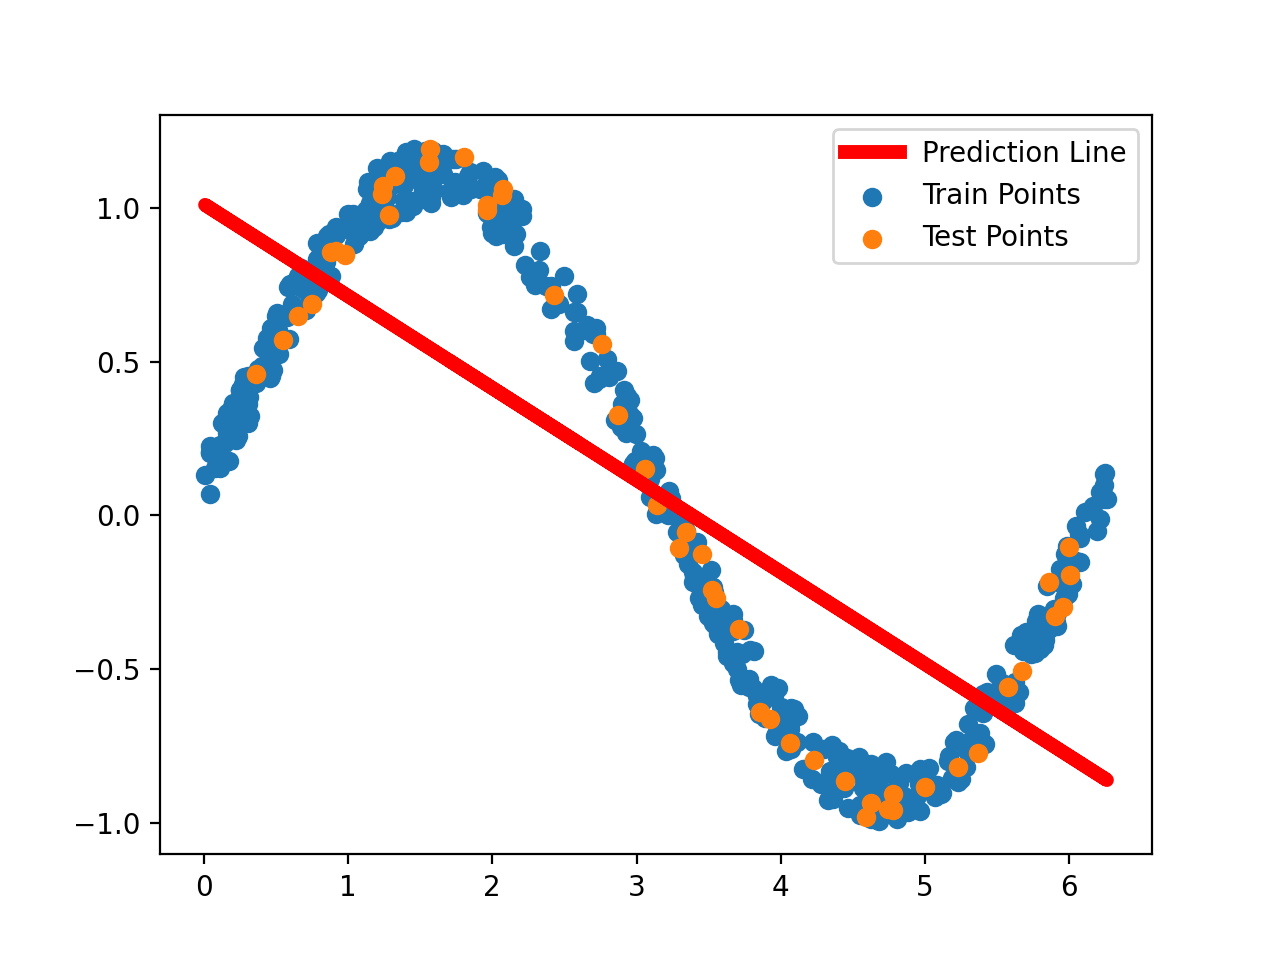

In [15]:
ndims = nl_xTr.shape[1]
linear_model = LinearRegressionModel(ndims)  # initialize the model
linear_model = train_regression_model(nl_xTr, nl_yTr,
                                      linear_model, 
                                      num_epochs=2000, 
                                      lr=1e-2, 
                                      print_freq=500)
avg_test_error = mse_loss(linear_model(nl_xTe), nl_yTe)  # compute the average test error
print('avg test error', avg_test_error.item())

# Visualize the results
plt.figure()
plt.plot(nl_xTr, linear_model(nl_xTr).detach(),linewidth=5.0, color="red", label="Prediction Line")
plt.scatter(nl_xTr, nl_yTr, label="Train Points")
plt.scatter(nl_xTe, nl_yTe, label="Test Points")
plt.legend()
plt.show()

Needless to say, a linear model doesn't model a sine function very well! Let's instead use our first neural network, a __Multi-Layer Perceptron model__. 

We need to define a few layers of the <code>MLPNet</code> using Pytorch, and implement the forward pass. For this network, write an MLP that has:
* Two fully connected layers: Use the Pytorch implementation, <code>nn.Linear(in_dim, out_dim)</code>. This will be updated automatically by Pytorch in our training loop.
* ReLU nonlinearities: Use the Pytorch implementation, <code>nn.functional.relu</code> between each of the linear layers.

In [16]:
# Create a Pytorch Multilayer Perceptron (MLP) Model
#<GRADED>
class MLPNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim=1):
        super(MLPNet, self).__init__()
        """ pytorch optimizer checks for the properties of the model, and if
            the torch.nn.Parameter requires gradient, then the model will update
            the parameters automatically.
        """
        self.input_dim = input_dim
        
        # Initialize the fully connected layers
        
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)
            
    
    def forward(self, x):
        # Implement the forward pass, with ReLU non-linearities
        x = x.view(x.size(0), -1)
        x = self.fc2(F.relu(self.fc1(x)))
        return x
#</GRADED>

How does the __hidden dimensions__ in an MLP affect the output results? Try out various hidden dimensions using the code provided. We highly recommend for you to play with different number of hidden nodes using the slider tool. Do more or less hidden nodes result in smoother regression outputs? What is the tradeoff?

<IPython.core.display.Javascript object>


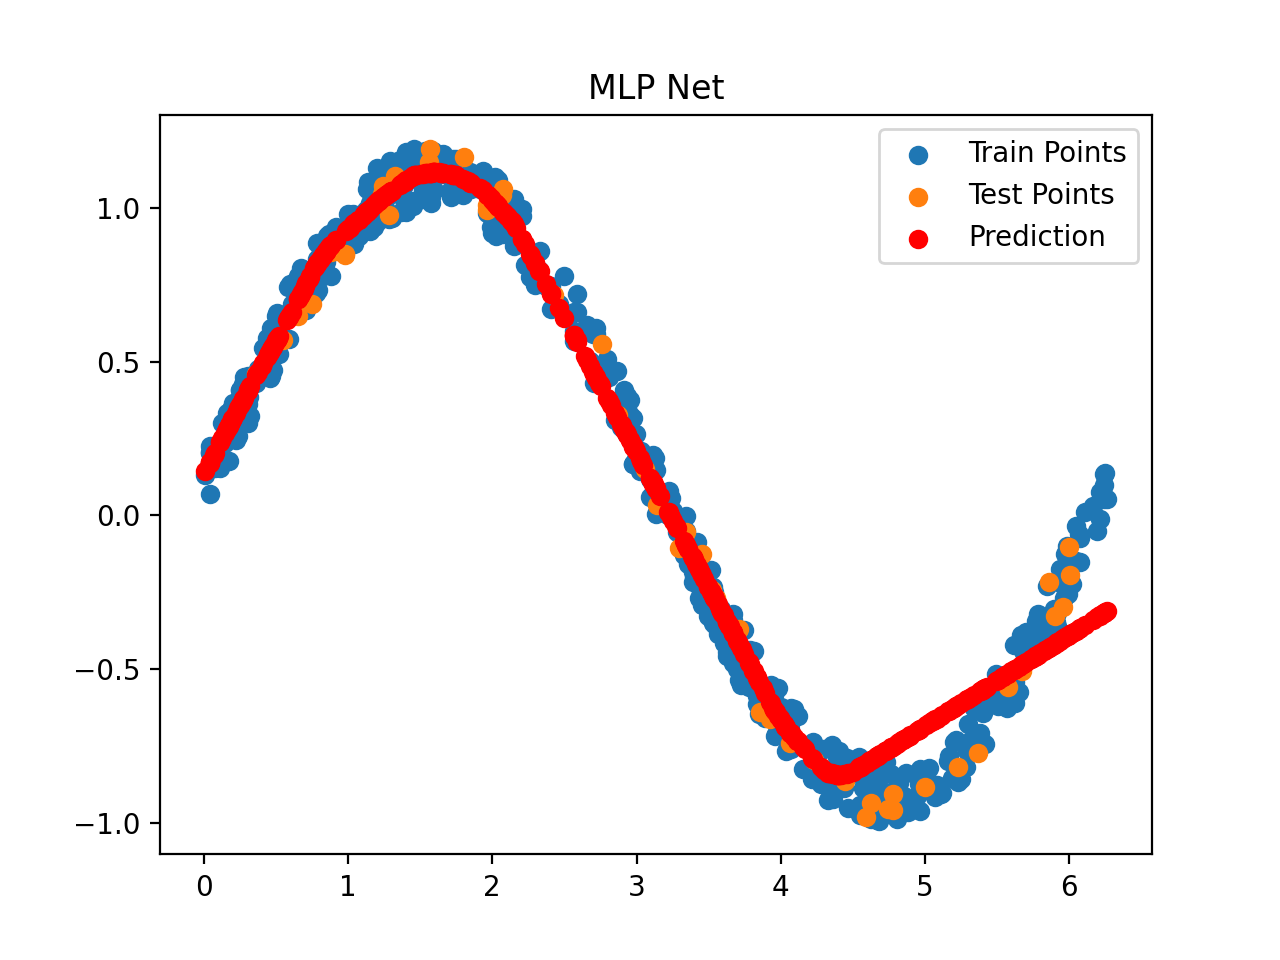

interactive(children=(IntSlider(value=1, description='hdims', min=1), Output()), _dom_classes=('widget-interac…

In [22]:
num_epochs = 2000
lr = 1e-3
trained_models = {}

fig = plt.figure()

def update(hdims):
    fig.clear()
    key = str(hdims)
    if key in trained_models:
        mlp_model = trained_models[key]
    else:
        mlp_model = MLPNet(input_dim=1, hidden_dim=hdims, output_dim=1)
        mlp_model = train_regression_model(nl_xTr, nl_yTr, mlp_model, num_epochs=num_epochs, lr=lr, display_loss=False)
        trained_models[key] = mlp_model
    plt.scatter(nl_xTr, nl_yTr, label="Train Points")
    plt.scatter(nl_xTe, nl_yTe, label="Test Points")
    plt.title('MLP Net')
    plt.scatter(nl_xTr, mlp_model(nl_xTr).detach(), color="red", marker='o', label="Prediction")
    plt.legend()
    fig.canvas.draw()

widgets.interact(update, hdims=widgets.IntSlider(value=1, min=1, max=100, step=1));

Run the regression train loop, <code>train_regression_model</code>, with the MLP model on the non-linear data. Use your favorite hidden dimension <code>hdim</code> from above to get the test error below 0.002. Additionally, what learning rates and number of epochs converges for the MLP model? To start, we suggest using <code>num_epochs = 5000</code>, and <code>lr = 1e-3</code>.

In [23]:
hdims = 20
num_epochs = 5000
lr = 1e-3

mlp_model = MLPNet(input_dim=1, hidden_dim=hdims, output_dim=1)
mlp_model = train_regression_model(nl_xTr, nl_yTr, mlp_model, num_epochs=num_epochs, lr=lr)
avg_test_error = mse_loss(mlp_model(nl_xTe), nl_yTe)
print('avg test error', avg_test_error.item())

epoch 100 loss 0.14987251162528992
epoch 200 loss 0.09740474820137024
epoch 300 loss 0.05399428680539131
epoch 400 loss 0.04257526248693466
epoch 500 loss 0.037236955016851425
epoch 600 loss 0.03457919508218765
epoch 700 loss 0.03280862420797348
epoch 800 loss 0.0313270203769207
epoch 900 loss 0.030026966705918312
epoch 1000 loss 0.02879357896745205
epoch 1100 loss 0.027593398466706276
epoch 1200 loss 0.026403827592730522
epoch 1300 loss 0.02520563267171383
epoch 1400 loss 0.023980598896741867
epoch 1500 loss 0.02267671562731266
epoch 1600 loss 0.021202323958277702
epoch 1700 loss 0.019587639719247818
epoch 1800 loss 0.01811143383383751
epoch 1900 loss 0.01666928082704544
epoch 2000 loss 0.015246429480612278
epoch 2100 loss 0.013833324424922466
epoch 2200 loss 0.01246238499879837
epoch 2300 loss 0.011144502088427544
epoch 2400 loss 0.009917696006596088
epoch 2500 loss 0.00879404041916132
epoch 2600 loss 0.0077875652350485325
epoch 2700 loss 0.006848874036222696
epoch 2800 loss 0.005994

Now, we have trained our first neural network model! Let's predict by passing in input data via <code>mlp_model(x)</code>. 

Visualize how good of a fit our MLP is to the data, as compared to the linear model via a side-by-side comparison:

<IPython.core.display.Javascript object>


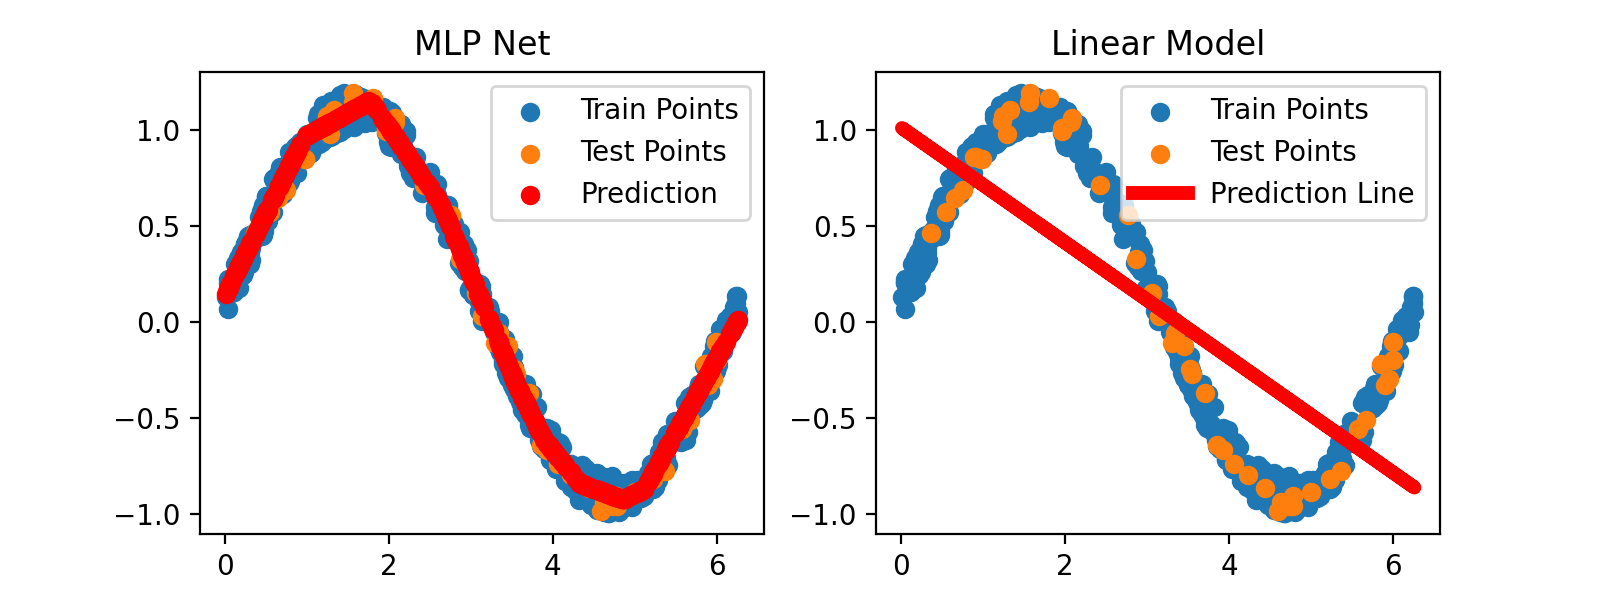

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8,3))

# Plot the visualizations from our MLP Model
ax1.scatter(nl_xTr, nl_yTr, label="Train Points")
ax1.scatter(nl_xTe, nl_yTe, label="Test Points")
ax1.scatter(nl_xTr, mlp_model(nl_xTr).detach(), color="red", marker='o', label="Prediction")
ax1.legend()
ax1.set_title('MLP Net')

# Plot the visualizations from our MLP Model
ax2.scatter(nl_xTr, nl_yTr, label="Train Points")
ax2.scatter(nl_xTe, nl_yTe, label="Test Points")
ax2.plot(nl_xTr, linear_model(nl_xTr).detach(),linewidth=5.0, color="red", label="Prediction Line")
ax2.legend()
ax2.set_title('Linear Model')

plt.show()

<h2>Handwritten Digits Classification</h2>

One of the tasks neural network models can solve quite well is classification! We will explore their capabilities on a simple classification task, classifying handwritten digits. Specifically, we will be taking an image of a digit between 0 - 9 and classifying which digit it is.




<center>
    <img src="320px-MnistExamples.png" width="400px" /></a>
</center>

For this task, we will look into the [MNIST dataset](http://yann.lecun.com/exdb/mnist/). The MNIST database consists of black and white handwritten digits, cropped to a fixed size. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting.

Fortunately for us, Pytorch provides an easy implementation to download the cleaned and already prepared data, using a few lines of code. Let us load it and visualize some of the images.

In [25]:
# Load the dataset
trans = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (1.0,))])
train_set = dset.MNIST(root=".", train=True, transform=trans, download=True)
train_subset_indices = np.load("train_subset_indices.npy")  # load a predefined subset for efficiency
train_set = torch.utils.data.Subset(train_set, train_subset_indices)
test_set = dset.MNIST(root=".", train=False, transform=trans, download=True)

batch_size = 64

train_loader = torch.utils.data.DataLoader(
                 dataset=train_set,
                 batch_size=batch_size,
                 shuffle=True)
test_loader = torch.utils.data.DataLoader(
                dataset=test_set,
                batch_size=batch_size,
                shuffle=False)

<IPython.core.display.Javascript object>


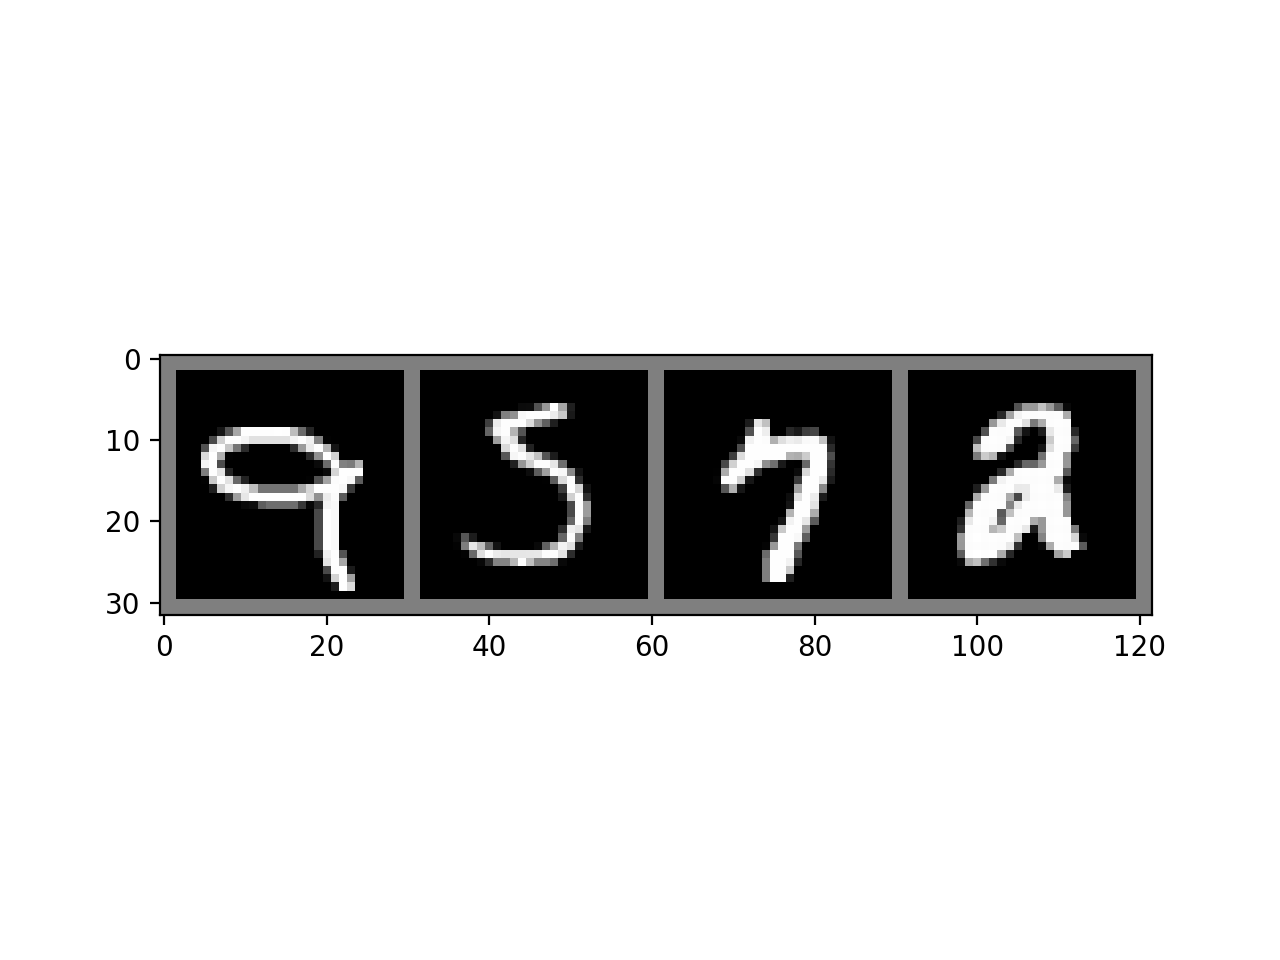

labels are: 9 5 7 2


In [26]:
def imshow(img):
    img = img + 0.5     # unnormalize
    plt.figure()
    plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))
    plt.show()

dataiter = iter(train_loader)
images, labels = next(dataiter)

num_show_img = 4
# show images
imshow(torchvision.utils.make_grid(images[:num_show_img]))
# print labels
print('labels are:', ' '.join('%d' % labels[j] for j in range(num_show_img)))

Update the regression train loop (given above in <code>train_regression_model</code>) to train a classification model instead. The key difference is the loss function used is _no longer the MSE loss_. 

We will instead use the cross entropy loss, which is implemented for us in Pytorch, <code>nn.functional.cross_entropy(predictions, labels)</code>. Implement the new training loop, <code>train_classification_model</code>, and assume that the prediction outputs from the model are in one-hot format. 

In [27]:
# Training function
#<GRADED>
def train_classification_model(train_loader, model, num_epochs, lr=1e-1, print_freq=100):
    """Train loop for a neural network model. Please use the SGD optimizer, optim.SGD.
    
    Input:
        train_loader:    Data loader for the train set. 
                         Enumerate through to train with each batch.
        model:           nn.Model to be trained
        num_epochs:      number of epochs to train the model for
        lr:              learning rate for the optimizer
        print_freq:      frequency to display the loss
    
    Output:
        model:   nn.Module trained model
    """
    optimizer = optim.SGD(model.parameters(), lr=lr)  # create an SGD optimizer for the model parameters
    model.train()
    
    for epoch in range(num_epochs):

        # Iterate through the dataloader for each epoch
        for batch_idx, (imgs, labels) in enumerate(train_loader):
            # imgs (torch.Tensor):    batch of input images
            # labels (torch.Tensor):  batch labels corresponding to the inputs
            # Implement the training loop using imgs, labels, and cross entropy loss
            optimizer.zero_grad()
            logits = model(imgs)
            if labels.ndim > 1:
                labels = torch.argmax(labels, dim=1)
            loss = F.cross_entropy(logits, labels)
            loss.backward()
            optimizer.step()

            if batch_idx % print_freq == 0:
                print(f"Epoch [{epoch+1}/{num_epochs}], Step [{batch_idx}], Loss: {loss.item():.4f}")
            
    return model  # return trained model
#</GRADED>

Additionally, implement the classification test function. Compute the accuracy of our model over the test set. We say that the predicted label is the digit that the model outputs the _maximum score_, and a correct prediction is one where the maximum score matches the true label. Return the average accuracy over all batches in the test set.

In [28]:
# Test function
#<GRADED>
def test_classification_model(test_loader, model):
    """Tests the accuracy of the model.
    
    Input:
        test_loader:      Data loader for the test set. 
                          Enumerate through to test each example.
        model:            nn.Module model being evaluate.
        
    Output:
        accuracy:         Accuracy of the model on the test set.
    """
    # Compute the model accuracy
    
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for _, (imgs, labels) in enumerate(test_loader):
            
            if labels.ndim > 1:
                labels = torch.argmax(labels, dim=1)
            logits = model(imgs)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    
    accuracy = correct / total
    
    return accuracy
#</GRADED>

Finally, we are ready to train an MLP neural network on this classification task! Initialize a <code>MLPNet</code> with the proper input dimension and output dimension. Play around with the hidden dimension to get the accuracy above 95\%. Additionally, what learning rates and number of epochs converges for the MLP model? To start, we suggest using <code>num_epochs = 40</code> and <code>lr = 1e-2</code>.

In [29]:
# Train an MLP model on MNSIT
hidden_dim = 40
num_epochs = 40
lr = 1e-2

mlp_model = MLPNet(input_dim=28*28, hidden_dim=hidden_dim, output_dim=10)
print('the number of parameters', sum(parameter.view(-1).size()[0] for parameter in mlp_model.parameters()))
mlp_model = train_classification_model(train_loader, mlp_model, num_epochs=num_epochs, lr=lr)
avg_test_acc = test_classification_model(test_loader, mlp_model)
print('avg test accuracy', avg_test_acc)

the number of parameters 31810
Epoch [1/40], Step [0], Loss: 2.3477
Epoch [1/40], Step [100], Loss: 2.0765
Epoch [2/40], Step [0], Loss: 1.8766
Epoch [2/40], Step [100], Loss: 1.6247
Epoch [3/40], Step [0], Loss: 1.3712
Epoch [3/40], Step [100], Loss: 1.1508
Epoch [4/40], Step [0], Loss: 1.0978
Epoch [4/40], Step [100], Loss: 0.9431
Epoch [5/40], Step [0], Loss: 0.8509
Epoch [5/40], Step [100], Loss: 0.7557
Epoch [6/40], Step [0], Loss: 0.7844
Epoch [6/40], Step [100], Loss: 0.6406
Epoch [7/40], Step [0], Loss: 0.8001
Epoch [7/40], Step [100], Loss: 0.5648
Epoch [8/40], Step [0], Loss: 0.6209
Epoch [8/40], Step [100], Loss: 0.5164
Epoch [9/40], Step [0], Loss: 0.5603
Epoch [9/40], Step [100], Loss: 0.4750
Epoch [10/40], Step [0], Loss: 0.4470
Epoch [10/40], Step [100], Loss: 0.5205
Epoch [11/40], Step [0], Loss: 0.4312
Epoch [11/40], Step [100], Loss: 0.3398
Epoch [12/40], Step [0], Loss: 0.4369
Epoch [12/40], Step [100], Loss: 0.3685
Epoch [13/40], Step [0], Loss: 0.4894
Epoch [13/40]

<h3>Convolutional Neural Networks</h3>

In class, we learned about about Convolutional Neural Networks (or CNN for short) that is explicity designed for image inputs. Let's implement and train a CNN on the MNIST dataset!

We need to define a few layers of the <code>ConvNet</code> using Pytorch, and implement the forward pass. For this network, write an CNN that has:
* Two convolutional layers: Use the Pytorch implementation, <code>nn.Conv2d(in_channels, out_channels)</code>. For each convolutional layer, set <code>kernel_size=3</code>, <code>stride=1</code>, <code>padding=1</code> and <code>bias=False</code>.
* ReLU nonlinearities: Use the Pytorch implementation, <code>nn.functional.relu</code> between each of the layers.
* Max-Pooling layers: Use the Pytorch implementation, <code>nn.functional.max_pool2d</code> to pool after each of the ReLU. For each max-pooling layer, set <code>kernel_size=2</code>, <code>stride=2</code>.
* Last layer a fully connected layer: Use the Pytorch implementation, <code>nn.Linear(in_dim, out_dim)</code>. <code>in_dim</code> depends on the size of input image (MNIST images), which is <code>28 * 28</code> in our case. Make sure to re-shape the input into a batch of vectors to pass it through the last layer using the function: <code>Tensor.view(*shape)</code>.

In [30]:
# Create Pytorch ConvNet Model
#<GRADED>
class ConvNet(nn.Module):
    def __init__(self, input_channels=1, hidden_channels=32, output_dim=1):
        super(ConvNet, self).__init__()
        
        # Initialize the ConvNet layers

        self.conv1 = nn.Conv2d(
            in_channels=input_channels,
            out_channels=hidden_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        
        self.conv2 = nn.Conv2d(
            in_channels=hidden_channels,
            out_channels=hidden_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
 
        self.fc = nn.Linear(49*hidden_channels, output_dim)
        
        
    def forward(self, x):
        # Implement the forward pass, with ReLU non-linearities and max-pooling
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, kernel_size=2, stride=2)
        
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, kernel_size=2, stride=2)
        
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        
        return x
#</GRADED>

Run the classificiation train loop, this time with the <code>ConvNet</code> implemented above. Try out different hidden channel dimension to obtain an accuracy above 95\%. (Hint: the channel dimension should not be above 50 for computational efficiency.)

Once again, what learning rates and number of epochs converges for the CNN model? To start, we suggest using <code>num_epochs = 40</code> and <code>lr = 1e-3</code>.

In [31]:
# Train a convnet model on MNIST
hidden_channels = 32
num_epochs = 40
lr = 1e-3

conv_model = ConvNet(input_channels=1, hidden_channels=hidden_channels, output_dim=10)
print('the number of parameters:', sum(parameter.view(-1).size()[0] for parameter in conv_model.parameters()))
conv_model = train_classification_model(train_loader, conv_model, num_epochs=num_epochs, lr=lr)
avg_test_acc = test_classification_model(test_loader, conv_model)
print('avg test accuracy', avg_test_acc)

the number of parameters: 25194
Epoch [1/40], Step [0], Loss: 2.3127
Epoch [1/40], Step [100], Loss: 2.3011
Epoch [2/40], Step [0], Loss: 2.3023
Epoch [2/40], Step [100], Loss: 2.2984
Epoch [3/40], Step [0], Loss: 2.3016
Epoch [3/40], Step [100], Loss: 2.2882
Epoch [4/40], Step [0], Loss: 2.2834
Epoch [4/40], Step [100], Loss: 2.2787
Epoch [5/40], Step [0], Loss: 2.2796
Epoch [5/40], Step [100], Loss: 2.2668
Epoch [6/40], Step [0], Loss: 2.2609
Epoch [6/40], Step [100], Loss: 2.2569
Epoch [7/40], Step [0], Loss: 2.2452
Epoch [7/40], Step [100], Loss: 2.2518
Epoch [8/40], Step [0], Loss: 2.2422
Epoch [8/40], Step [100], Loss: 2.2391
Epoch [9/40], Step [0], Loss: 2.2091
Epoch [9/40], Step [100], Loss: 2.2019
Epoch [10/40], Step [0], Loss: 2.1906
Epoch [10/40], Step [100], Loss: 2.2116
Epoch [11/40], Step [0], Loss: 2.1940
Epoch [11/40], Step [100], Loss: 2.1736
Epoch [12/40], Step [0], Loss: 2.1424
Epoch [12/40], Step [100], Loss: 2.1029
Epoch [13/40], Step [0], Loss: 2.0985
Epoch [13/40

<IPython.core.display.Javascript object>


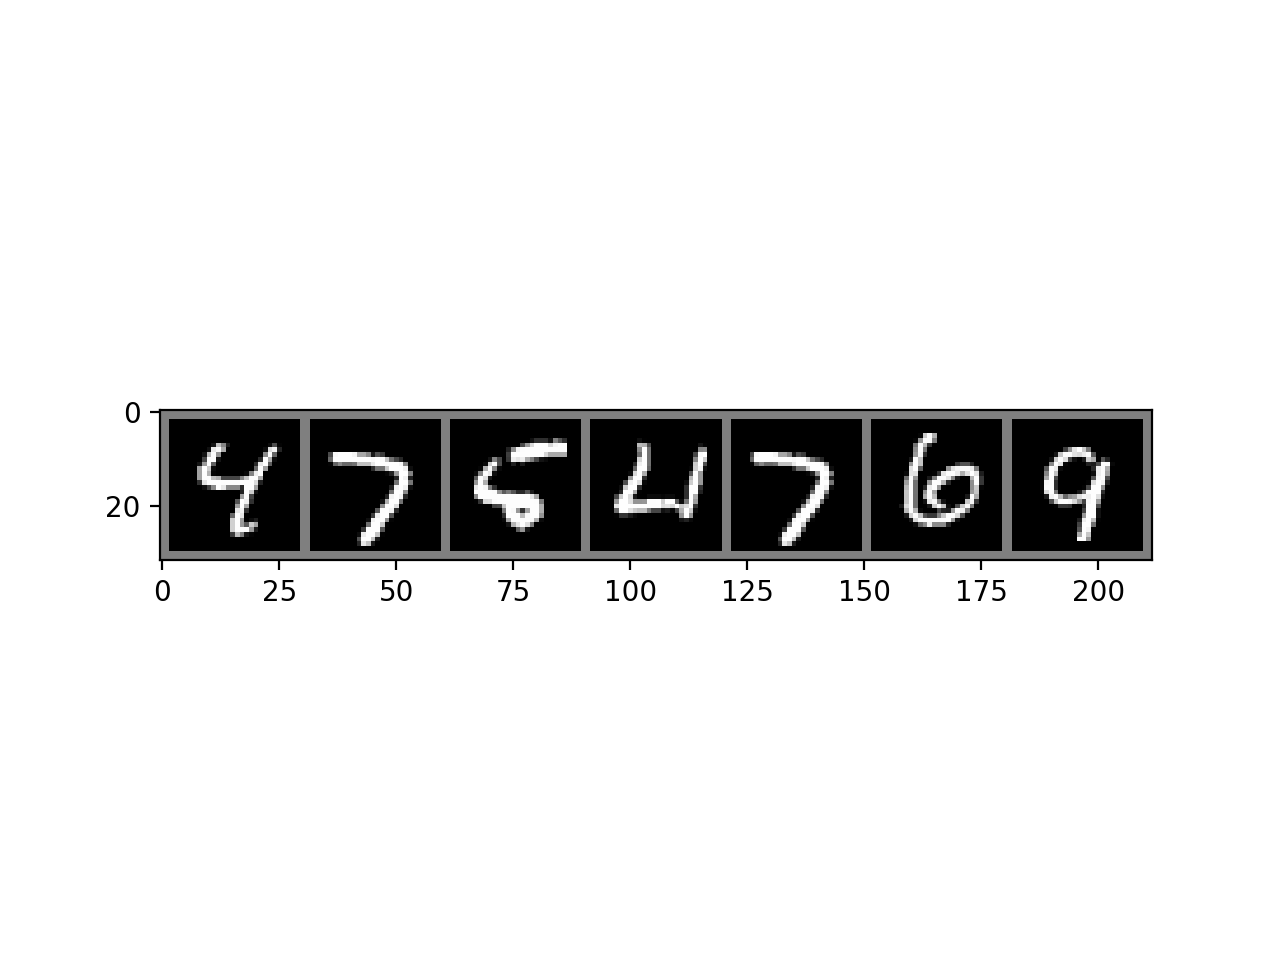

labels are: 4 7 5 4 7 6 9
MLP predictions are: 4 7 6 6 7 6 9
CNN predictions are: 4 7 5 0 7 6 9


In [32]:
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Make a forward pass to get predictions of the MLP model
mlp_scores = mlp_model(images)
_, mlp_preds = torch.max(mlp_scores.data, 1)

# Make a forward pass to get predictions of the ConvNet model
conv_scores = conv_model(images)
_, conv_preds = torch.max(conv_scores.data, 1)

show_img_idx = np.random.randint(images.shape[0], size=7)
# show images
imshow(torchvision.utils.make_grid(images[show_img_idx]))
# print labels
print('labels are:', ' '.join('%d' % labels[j] for j in show_img_idx))
# print predictions
print('MLP predictions are:', ' '.join('%d' % mlp_preds[j] for j in show_img_idx))
print('CNN predictions are:', ' '.join('%d' % conv_preds[j] for j in show_img_idx))

<h3>Why Do CNN's Work?</h3>

Let's try to build some intuition behind why Convolution Neural Networks work well for image inputs.

For a toy experiment, let's shuffle the pixels for each of the input images, _but only in a set order_. Would we expect to see ConvNet's still working better than MLP?

In [33]:
# Load the shuffled dataset
torch.manual_seed(0)
trans = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (1.0,))])
pixel_shuffle_train_set = dset.MNIST(root=".", train=True, transform=trans, download=True)
train_subset_indices = np.load("train_subset_indices.npy")  # load a subset for efficiency
pixel_shuffle_train_set = torch.utils.data.Subset(pixel_shuffle_train_set, train_subset_indices)
pixel_shuffle_test_set = dset.MNIST(root=".", train=False, transform=trans, download=True)

randperm = torch.randperm(28 * 28)
pixel_shuffle_train_set.dataset.data = pixel_shuffle_train_set.dataset.data.view(-1, 28 * 28)[:, randperm].view(-1, 28, 28)
pixel_shuffle_test_set.data = pixel_shuffle_test_set.data.view(-1, 28 * 28)[:, randperm].view(-1, 28, 28)

batch_size = 64
pixel_shuffle_train_loader = torch.utils.data.DataLoader(
                 dataset=pixel_shuffle_train_set,
                 batch_size=batch_size,
                 shuffle=True)
pixel_shuffle_test_loader = torch.utils.data.DataLoader(
                dataset=pixel_shuffle_test_set,
                batch_size=batch_size,
                shuffle=False)

<IPython.core.display.Javascript object>


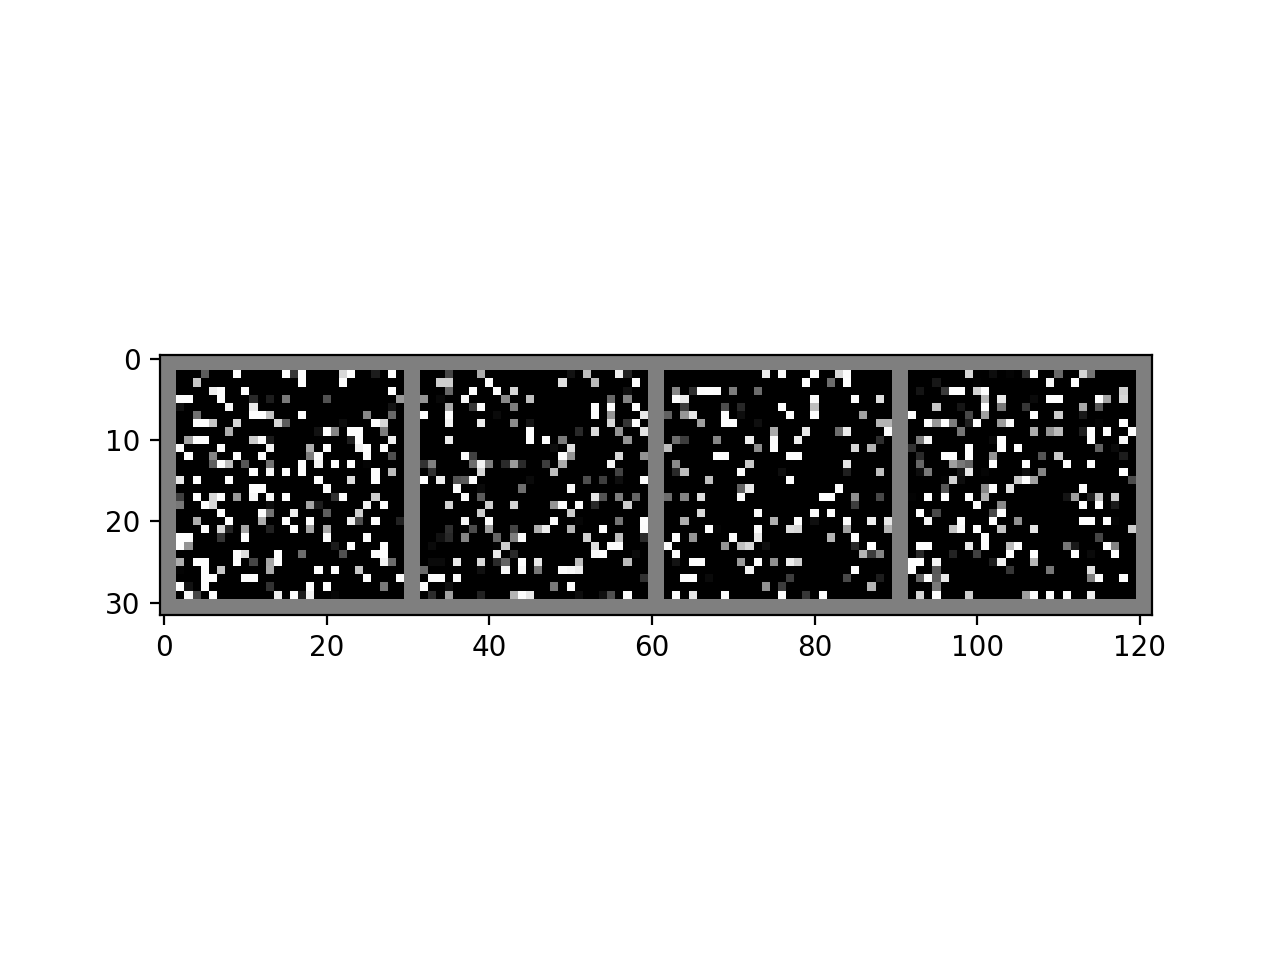

labels are: 2 0 8 9


In [34]:
dataiter = iter(pixel_shuffle_train_loader)
images, labels = next(dataiter)

num_show_img = 4
# show shuffled images
imshow(torchvision.utils.make_grid(images[:num_show_img]))
# print labels
print('labels are:', ' '.join('%d' % labels[j] for j in range(num_show_img)))

It looks like kind of a mess! But let's train an MLP model anyways, as before, and observe the new test accuracy on this shuffled-pixel dataset. __Use the same hyperparameters as you did before__.

In [35]:
# Train an MLP model on pixel-shuffled MNSIT
hidden_channels = 32
num_epochs = 40
lr = 1e-3

mlp_model = MLPNet(input_dim=28*28, hidden_dim=hidden_dim, output_dim=10)
print('the number of parameters:', sum(parameter.view(-1).size()[0] for parameter in mlp_model.parameters()))
mlp_model = train_classification_model(pixel_shuffle_train_loader, mlp_model, num_epochs=num_epochs, lr=lr)
avg_test_acc = test_classification_model(pixel_shuffle_test_loader, mlp_model)
print('avg test accuracy', avg_test_acc)

the number of parameters: 31810
Epoch [1/40], Step [0], Loss: 2.3033
Epoch [1/40], Step [100], Loss: 2.2525
Epoch [2/40], Step [0], Loss: 2.2778
Epoch [2/40], Step [100], Loss: 2.2428
Epoch [3/40], Step [0], Loss: 2.2310
Epoch [3/40], Step [100], Loss: 2.2158
Epoch [4/40], Step [0], Loss: 2.2147
Epoch [4/40], Step [100], Loss: 2.2001
Epoch [5/40], Step [0], Loss: 2.1593
Epoch [5/40], Step [100], Loss: 2.1872
Epoch [6/40], Step [0], Loss: 2.0818
Epoch [6/40], Step [100], Loss: 2.0625
Epoch [7/40], Step [0], Loss: 2.0468
Epoch [7/40], Step [100], Loss: 2.0307
Epoch [8/40], Step [0], Loss: 2.0201
Epoch [8/40], Step [100], Loss: 2.0030
Epoch [9/40], Step [0], Loss: 1.9959
Epoch [9/40], Step [100], Loss: 2.0126
Epoch [10/40], Step [0], Loss: 1.9889
Epoch [10/40], Step [100], Loss: 1.9634
Epoch [11/40], Step [0], Loss: 1.8876
Epoch [11/40], Step [100], Loss: 1.9018
Epoch [12/40], Step [0], Loss: 1.8520
Epoch [12/40], Step [100], Loss: 1.7841
Epoch [13/40], Step [0], Loss: 1.8868
Epoch [13/40

Additionally, train a CNN model, as before, and observe the new test accuracy on this shuffled-pixel dataset. __Use the same hyperparameters as you did before__.

In [36]:
# Train a ConvNet model on pixel-shuffled MNSIT
hidden_channels = 32
num_epochs = 40
lr = 1e-3

conv_model = ConvNet(input_channels=1, hidden_channels=hidden_channels, output_dim=10)
print('the number of parameters:', sum(parameter.view(-1).size()[0] for parameter in conv_model.parameters()))
conv_model = train_classification_model(pixel_shuffle_train_loader, conv_model, num_epochs=num_epochs, lr=lr)
avg_test_acc = test_classification_model(pixel_shuffle_test_loader, conv_model)
print('avg test accuracy', avg_test_acc)

the number of parameters: 25194
Epoch [1/40], Step [0], Loss: 2.3033
Epoch [1/40], Step [100], Loss: 2.3168
Epoch [2/40], Step [0], Loss: 2.3090
Epoch [2/40], Step [100], Loss: 2.2900
Epoch [3/40], Step [0], Loss: 2.2901
Epoch [3/40], Step [100], Loss: 2.2868
Epoch [4/40], Step [0], Loss: 2.2823
Epoch [4/40], Step [100], Loss: 2.2875
Epoch [5/40], Step [0], Loss: 2.2753
Epoch [5/40], Step [100], Loss: 2.2817
Epoch [6/40], Step [0], Loss: 2.2773
Epoch [6/40], Step [100], Loss: 2.2773
Epoch [7/40], Step [0], Loss: 2.2721
Epoch [7/40], Step [100], Loss: 2.2865
Epoch [8/40], Step [0], Loss: 2.2633
Epoch [8/40], Step [100], Loss: 2.2560
Epoch [9/40], Step [0], Loss: 2.2469
Epoch [9/40], Step [100], Loss: 2.2425
Epoch [10/40], Step [0], Loss: 2.2391
Epoch [10/40], Step [100], Loss: 2.2364
Epoch [11/40], Step [0], Loss: 2.2469
Epoch [11/40], Step [100], Loss: 2.2338
Epoch [12/40], Step [0], Loss: 2.2301
Epoch [12/40], Step [100], Loss: 2.2336
Epoch [13/40], Step [0], Loss: 2.2170
Epoch [13/40

Observe that the accuracy is now _slightly lower than_ that of MLP models! This shows that CNN's utilize the stucture of the image (i.e., pixel proximity) to make their predictions. With the pixel orders shuffled, it is no longer as good of a model.

Let us visualize some of the prediction results.

In [ ]:
dataiter = iter(pixel_shuffle_test_loader)
images, labels = next(dataiter)

# Make a forward pass to get predictions of the MLP model
mlp_scores = mlp_model(images)
_, mlp_preds = torch.max(mlp_scores.data, 1)

# Make a forward pass to get predictions of the ConvNet model
conv_scores = conv_model(images)
_, conv_preds = torch.max(conv_scores.data, 1)

show_img_idx = np.random.randint(images.shape[0], size=7)
# show images
imshow(torchvision.utils.make_grid(images[show_img_idx]))
# print labels
print('labels are:', ' '.join('%d' % labels[j] for j in show_img_idx))
# print predictions
print('MLP predictions are:', ' '.join('%d' % mlp_preds[j] for j in show_img_idx))
print('CNN predictions are:', ' '.join('%d' % conv_preds[j] for j in show_img_idx))